# RQ3 matched-budget — does calibration follow the parameter budget, or the backbone?

Implements [`docs/RQ3_MATCHED_BUDGET_PLAN.md`](../docs/RQ3_MATCHED_BUDGET_PLAN.md) end to end.

**The gap this closes.** RQ3's 16 bottleneck-vs-LoRA pairs show the *accuracy* winner never
changing when the parameter-budget ordering reverses between backbones, while the *calibration*
winner changes exactly in step with it. But the reversal is welded to the backbone — bottleneck is
the larger arm on ResNet-18 (31,744 vs 12,288) and the smaller one on MobileNetV3-Small (6,928 vs
10,752) — so two accounts predict the identical 16/16 pattern and the existing grid **cannot
separate them**:

| | prediction at *matched* budget |
|---|---|
| **H3.1** — architecture | one architecture is better calibrated regardless of budget |
| **H3.2** — budget | the sign flip disappears; gaps collapse toward zero on both backbones |
| **H3.2-alt** — backbone-intrinsic | the original per-backbone signs persist anyway |

Building both architectures at the **same budget within each backbone** breaks the weld. The
decision rule is pre-registered in code (`rq3_matched.DECISION_RULES`) *before* any result exists.

**The design — 5 new arms, 30 new runs** (MiniImageNet, 5-shot, 3 seeds, both heads trained
separately):

| Backbone | Level | bottleneck | LoRA | mismatch |
|---|---|---|---|---:|
| ResNet-18 | L ≈ 12.4k | **rank 6** (new) | rank 16 (grid) | 1.76% |
| ResNet-18 | H ≈ 31.6k | rank 16 (grid) | **rank 41** (new) | 0.81% |
| MobileNetV3-S | L ≈ 6.8k | rank 16 (grid) | **rank 10** (new) | 3.10% |
| MobileNetV3-S | H ≈ 9.4k | **rank 22** (new) | **rank 14** (new) | 0.43% |

against **55–158%** mismatch in the original comparison. Three arms already exist as Step 10 grid
cells, so their checkpoints are reused and their metrics double as a sanity check that this harness
measures what the grid measured.

**Kaggle settings:** Accelerator **GPU T4**, Internet **ON**, and attach:

1. **`beft-thesis-data`** (owner `notavailable73`) — MiniImageNet / SVHN / TinyImageNet / CIFAR-100.
   Everything falls back to a runtime download, so this is a speed-up, not a requirement.
2. **`step10c_mini_artifacts.zip`** (or the step10c notebook's output) — holds all **18** Step 10
   twin checkpoints the three existing arms reuse. Without it those 18 cells retrain (~5 GPU-h of
   avoidable work).
3. **the previous session's `rq3_matched_results.zip` / `rq3_matched_checkpoints.zip`**, if this is
   not your first session — that is what makes the sweep resume instead of restart.

**Budget.** 30 new runs at the grid's measured 1,054 s/run ≈ **8.8 GPU-hours**, plus ~3 min/cell to
evaluate all 48 cells. That is **2–3 Kaggle sessions**; everything is resumable and `MAX_MINUTES`
stops cleanly mid-sweep.

**Self-contained.** All *new* logic is written out by Section 3 with `%%writefile`, so the source
lives in this `.ipynb` and travels back in the artifact zip. The repo is still cloned, because the
model, datasets, frozen episode seeds, the run drivers — and critically
`PrototypeHead.to_evidence` — come from it. The evidence map is **never** reimplemented here: that
exact train/eval drift caused the Step 4 evidential collapse.


## 0. Control panel — the only cell you normally edit

Every stage is **resumable**: a cell whose output JSON already exists is skipped, so re-running this
notebook after a session timeout picks up where it stopped. `MAX_MINUTES` finishes the run in flight
and then stops cleanly, which is what makes a ~12 h job survivable in ~9 h sessions.


In [1]:
# ---- What to run this session -------------------------------------------
RUN_PREFLIGHT = True    # §4: config generation + parameter assertion + control guard (no GPU time)
RUN_SMOKE_EVAL = True   # §6: 5-episode end-to-end dry run before the long sweep (~2 min)
RUN_SWEEP     = True    # §7: the actual 48-cell train/evaluate sweep
RUN_VERDICT   = True    # §8: aggregate + adjudicate (safe to run on a partial sweep)

# ---- Sweep scope ---------------------------------------------------------
# Filter keys: backbone, level, arm, head, seed, status. Empty = the full design.
#   'backbone': 'resnet18' | 'mobilenetv3_small'
#   'level'   : 'L' | 'H'          'arm': 'btl' | 'lora'
#   'head'    : 'evidential' | 'softmax'
#   'status'  : 'existing' (a Step 10 grid arm) | 'new'
# Leave empty. The run order already completes one whole (backbone, level, head)
# comparison — 6 runs — before starting the next, so a session that stops early
# still yields interpretable pairs. ResNet-18 runs first: largest gaps to close.
ONLY = {}

NUM_EPISODES = 600      # the frozen test seeds 0..599; lower ONLY for smoke tests
MAX_MINUTES  = 480.0    # stop cleanly after this long (Kaggle T4 caps ~9 h)

REUSE_GRID_CHECKPOINTS = True   # reuse Step 10 twins for the three existing arms
RECOVER_SEARCH_ROOTS = ('/kaggle/input',)   # where to hunt for attached artifacts

# ---- Misc ---------------------------------------------------------------
PERSIST_LOGITS = False    # ~12 MB/cell (~600 MB for 48); makes future re-scoring free
PACK_CHECKPOINTS = True   # second zip (~600 MB) — this is what lets the NEXT session resume
WANDB_MODE = 'disabled'   # 'online' needs a WANDB_API_KEY Kaggle Secret
CACHE_OOD_IMAGES = True   # ~1.2 GB host RAM, saves reloading OOD pools per cell

print('stages:', {'preflight': RUN_PREFLIGHT, 'smoke': RUN_SMOKE_EVAL,
                  'sweep': RUN_SWEEP, 'verdict': RUN_VERDICT},
      '| filter:', ONLY, '| episodes:', NUM_EPISODES)


stages: {'preflight': True, 'smoke': True, 'sweep': True, 'verdict': True} | filter: {} | episodes: 600


## 1. GPU check + clone repo + install deps

In [2]:
import os, subprocess, sys
import torch

print('python:', sys.version.split()[0], '| torch:', torch.__version__)
print('cuda  :', torch.cuda.is_available(),
      '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')
if not torch.cuda.is_available():
    print('WARNING: no GPU (Settings > Accelerator > GPU T4). The pre-flight in Section 4 '
          'still runs fine on CPU — it is pure model construction — but a 600-episode '
          'evaluation takes hours instead of minutes, and training is not viable.')

REPO_URL = 'https://github.com/notAvailable73/thesis.git'
BRANCH   = 'main'
REPO_DIR = '/kaggle/working/thesis' if os.path.isdir('/kaggle/working') else os.path.abspath('./thesis')

if not os.path.isdir(os.path.join(REPO_DIR, '.git')):
    subprocess.run(['git', 'clone', '--branch', BRANCH, REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(['git', '-C', REPO_DIR, 'fetch', 'origin'], check=True)
    subprocess.run(['git', '-C', REPO_DIR, 'checkout', BRANCH], check=True)
    subprocess.run(['git', '-C', REPO_DIR, 'reset', '--hard', f'origin/{BRANCH}'], check=True)
os.chdir(REPO_DIR)
subprocess.run(['pip', 'install', '-q', '-r', 'requirements.txt'], check=True)

# Both are needed: the repo root for `src.*` / `scripts.*`, and scripts/ itself
# because rq_core / rq_drivers / rq_aggregate import each other by bare name.
sys.path.insert(0, os.getcwd())
sys.path.insert(0, os.path.join(os.getcwd(), 'scripts'))

from pathlib import Path
REPO = Path(os.getcwd())
print('repo ready at', REPO)
print('HEAD:', subprocess.run(['git', 'log', '-1', '--oneline'],
                              capture_output=True, text=True).stdout.strip())


python: 3.12.13 | torch: 2.10.0+cu128
cuda  : True | Tesla T4


Cloning into '/kaggle/working/thesis'...


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 975.7 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 2.8 MB/s eta 0:00:00
repo ready at /kaggle/working/thesis
HEAD: 142c89f Merge pull request #14 from notAvailable73/Review


## 2. Stage data — symlink the attached Kaggle dataset into `data/`

Nothing here is required: every dataset falls back to a runtime download if its source is missing
(Internet must be ON). This reuses the **same staged-path finder functions** `scripts/train.py` /
`evaluate.py` call at runtime, so it is guaranteed to point at whatever those modules would discover
themselves — correct regardless of how deep Kaggle happens to mount the dataset.

`build_grid_configs.py` is run because the three *existing* arms are matched to their Step 10 twins
through `configs/grid/_index.json`. It is idempotent and never regenerates a frozen split.


In [3]:
import shutil

from src.datasets.cifar_fs import _find_staged_cifar100_root
from src.datasets.svhn_ood import _find_staged_svhn_root
from src.datasets.tinyimagenet_ood import _find_extracted_tin_root
from src.datasets.mini_imagenet import _find_zenodo_pkls

LINKS = {}
if (root := _find_staged_cifar100_root('data')):
    LINKS['data/cifar-100-python'] = os.path.join(root, 'cifar-100-python')
if (root := _find_staged_svhn_root('data')):
    LINKS['data/svhn/test_32x32.mat'] = os.path.join(root, 'test_32x32.mat')
if (root := _find_extracted_tin_root('data')):
    LINKS['data/tiny-imagenet-200'] = root
for _split, _pkl in (_find_zenodo_pkls('data') or {}).items():
    LINKS[f'data/{_pkl.name}'] = str(_pkl)

os.makedirs('data/svhn', exist_ok=True)
if not LINKS:
    print('No staged files under /kaggle/input -- did you attach `beft-thesis-data`? '
          'Falling back to runtime downloads for everything.')
for link, target in LINKS.items():
    if os.path.exists(link) or os.path.islink(link):
        print(f'OK   (already present): {link}')
        continue
    if not os.path.exists(target):
        print(f'MISSING source -- {os.path.basename(link)} will download at runtime')
        continue
    try:
        os.symlink(target, link)
        print(f'OK   (symlinked): {link}')
    except OSError as e:
        print(f'symlink failed ({e}); copying instead: {link}')
        (shutil.copytree if os.path.isdir(target) else shutil.copy2)(target, link)

# Frozen splits + the 120 grid configs (idempotent; never regenerates committed JSON).
subprocess.run([sys.executable, 'scripts/build_mini_imagenet_split.py'], check=True)
subprocess.run([sys.executable, 'scripts/build_cifar_fs_split.py'], check=True)
subprocess.run([sys.executable, 'scripts/build_grid_configs.py'], check=True)
print('\nMiniImageNet split + grid index ready')


OK   (symlinked): data/cifar-100-python
OK   (symlinked): data/svhn/test_32x32.mat
OK   (symlinked): data/tiny-imagenet-200
OK   (symlinked): data/mini-imagenet-cache-train.pkl
OK   (symlinked): data/mini-imagenet-cache-validation.pkl
OK   (symlinked): data/mini-imagenet-cache-test.pkl
wrote /kaggle/working/thesis/data/mini_imagenet_split.json  (64/16/20, disjoint, union=100, status=canonical_ravi_larochelle)
wrote /kaggle/working/thesis/data/cifar_fs_split.json  (64/16/20, disjoint, union=100, status=canonical_bertinetto_via_torchmeta)
wrote 120 configs to /kaggle/working/thesis/configs/grid/ (96 PEFT + 24 baseline)
wrote /kaggle/working/thesis/configs/grid/_index.json
  priority 1: 36 cells
  priority 2: 24 cells
  priority 3: 36 cells
  priority 4: 24 cells

MiniImageNet split + grid index ready


## 3. The new code — `rq3_matched.py`

One module, written out from this notebook so the source lives in the `.ipynb` and travels back in
the artifact zip ready to be promoted into `scripts/`. It carries the whole plan:

| Plan | In the module |
|---|---|
| §3–§4 design + parameter formulas | `BACKBONES`, `DESIGN`, `expected_trainable_params` |
| §6 Step 1 config generation | `build_matched_configs` — minimal overrides, never a copied recipe |
| §6 Step 2 parameter assertion | `assert_parameter_budgets` — instantiated vs intended, before any GPU time |
| §6 Step 3 control guard | `assert_matched_arms_controlled` — on **merged** configs |
| §6 Step 4 driver | `restore_session_artifacts`, `run_matched_sweep` |
| §5 + §6 Step 5 adjudication | `DECISION_RULES`, `adjudicate`, `build_verdict` |

Nothing scientific is reimplemented: training goes through the real `scripts/train.py:main()`,
evaluation through `rq_core.factorial_evaluate` (and therefore through `PrototypeHead.to_evidence`),
and the checkpoint / results naming through `scripts/train.py`'s own `_checkpoint_tag` /
`_head_descriptor`. `build_verdict` reuses `rq_aggregate.load_records` rather than re-globbing.


In [4]:
%%writefile rq3_matched.py
"""RQ3 matched-budget experiment — config generation, guards, driver, verdict.

Implements docs/RQ3_MATCHED_BUDGET_PLAN.md. The question it exists to close:

    RQ3's 16 bottleneck-vs-LoRA pairs show the ACCURACY winner never changing
    when the parameter-budget ordering reverses between backbones, while the
    CALIBRATION winner changes exactly in step with it. But the reversal is
    welded to the backbone (bottleneck is the larger arm on ResNet-18, the
    smaller one on MobileNetV3-Small), so two accounts predict the identical
    16/16 pattern and the existing grid cannot separate them:

        H3.2      (budget)            — the larger-budget arm wins calibration
        H3.2-alt  (backbone-intrinsic)— something about the backbone does

    Building BOTH architectures at the SAME budget WITHIN each backbone breaks
    the weld: H3.1 (architecture), H3.2 and H3.2-alt then predict different
    things for the first time (see `DECISION_RULES` / `adjudicate`).

Design decisions, all deliberate and all from the plan:

§2.1  Both arms of a comparison inherit the SAME training recipe. Every
      generated config is a MINIMAL OVERRIDE (`adapter.rank` + bookkeeping) on
      the parent the Step 10 grid itself used, so LR / epochs / patience / KL
      schedule / evidence affine arrive by inheritance and can never be
      hand-copied out of sync. `assert_matched_arms_controlled` proves this on
      the MERGED configs, not the YAML source, so a difference inherited from a
      parent cannot hide.

§2.2  Bottleneck `rank` must not exceed the SHALLOWEST stage's channel count.
      `Conv1x1Bottleneck(channels, rank)` builds `Conv2d(channels, rank, 1)`;
      with `rank > channels` that is an over-complete projection, not a
      bottleneck. MobileNetV3-Small's shallowest placement stage is 24 channels
      (features.3), so its bottleneck ranks are capped at 23 — which is why
      Level H is rank 22/14 rather than the tighter-matching rank 25.

§2.3  MiniImageNet 5-shot only. RQ3's ECE effects clear 2x the across-seed SD
      in 8/8 MiniImageNet pairs but only 2/8 CIFAR-FS pairs, so a null on
      CIFAR-FS would be indistinguishable from insufficient power.
      `k_shot: 5` is base.yaml's default and is deliberately NOT overridden.

§2.4  Both head interpretations are TRAINED SEPARATELY, never read off one
      checkpoint. RQ3's original 16 pairs used separately trained evidential
      and softmax cells; reading softmax off an evidential parent would not be
      the same experiment. This is why the run count is x2.

Nothing scientific is reimplemented here: training goes through the real
`scripts/train.py:main()`, evaluation through `rq_core.factorial_evaluate`
(and therefore through `PrototypeHead.to_evidence`, the single source of truth
for the evidence map), and the checkpoint / results naming through
`scripts/train.py`'s own `_checkpoint_tag` / `_head_descriptor`.
"""
from __future__ import annotations

import json
import math
import shutil
import time
import zipfile
from pathlib import Path

import numpy as np
import yaml

from src.utils import load_config, count_trainable_params
from src.models import build_model
from scripts.train import _head_descriptor, _checkpoint_tag


# =====================================================================
# §3/§4 — the design, and the parameter formulas it is built from
# =====================================================================
#: Per-backbone facts the design depends on. Every number here was derived
#: from source (src/adapters/placement.py, src/adapters/lora.py) and validated
#: against the committed rank-16 `n_params` in results/mvt_results.json.
BACKBONES = {
    "resnet18": {
        "short": "r18",
        # resolve_stage_paths -> layer{1..4}.1; channels 64/128/256/512.
        "stage_channels": (64, 128, 256, 512),
        # _DEFAULT_LORA_TARGETS -> layer4.0.downsample.0 (256 -> 512).
        "lora_in_out": (256, 512),
        "parents": {"btl": "exp_phase5_mini_parallel_{head}.yaml",
                    "lora": "exp_phase5_mini_lora_{head}.yaml"},
        "common_ancestor": "exp_phase5_mini_base_{head}.yaml",
    },
    "mobilenetv3_small": {
        "short": "mnv3",
        # mobilenetv3_stage_paths -> features.{3,6,8,11}; widths 24/40/48/96.
        "stage_channels": (24, 40, 48, 96),
        # _mobilenetv3_default_lora_target -> features.11.block.3.0 (576 -> 96).
        "lora_in_out": (576, 96),
        "parents": {"btl": "exp_phase5_mini_mbnet_parallel_{head}.yaml",
                    "lora": "exp_phase5_mini_mbnet_lora_{head}.yaml"},
        "common_ancestor": "exp_phase5_mini_mbnet_postpool_{head}.yaml",
    },
}

HEADS = ("evidential", "softmax")
SEEDS = (42, 43, 44)

#: `grid_adapter` is the label configs/grid/_index.json uses, so an existing
#: arm can be matched to its Step 10 twin without re-deriving the convention.
ARMS = {"btl": {"adapter_type": "bottleneck", "grid_adapter": "bottleneck_parallel"},
        "lora": {"adapter_type": "lora", "grid_adapter": "lora"}}

#: §4 — 2 backbones x 2 matched budget levels x 2 arms. `status` is "existing"
#: when the arm IS a Step 10 grid cell (rank 16 on the same parent), so its
#: checkpoint can be reused instead of retrained, and its metrics double as the
#: §7 sanity check that this harness measures the same thing the grid did.
DESIGN = [
    # backbone,             level, arm,    rank, status
    ("resnet18",            "L",   "lora", 16,   "existing"),
    ("resnet18",            "L",   "btl",   6,   "new"),
    ("resnet18",            "H",   "btl",  16,   "existing"),
    ("resnet18",            "H",   "lora", 41,   "new"),
    ("mobilenetv3_small",   "L",   "btl",  16,   "existing"),
    ("mobilenetv3_small",   "L",   "lora", 10,   "new"),
    ("mobilenetv3_small",   "H",   "btl",  22,   "new"),
    ("mobilenetv3_small",   "H",   "lora", 14,   "new"),
]

#: §7 — a level whose two arms differ by more than this is not "matched" and
#: the experiment is void. The binding case is MobileNetV3 Level L
#: (6,928 vs 6,720 = 3.10% of the smaller arm).
MAX_BUDGET_MISMATCH_PCT = 3.1

#: §5 — the unmatched ΔECE baselines from the existing grid (MiniImageNet
#: 5-shot), PRE-REGISTERED here so the collapse criterion cannot be computed
#: against a number chosen after seeing the result. `unmatched_deltas()`
#: recomputes them from results/mvt_results.json and asserts they agree.
PREREGISTERED_UNMATCHED_DELTA_ECE = {
    ("resnet18", "evidential"): +0.1111,
    ("resnet18", "softmax"): +0.1080,
    ("mobilenetv3_small", "evidential"): -0.0124,
    ("mobilenetv3_small", "softmax"): -0.0152,
}

#: §5 — the collapse criterion for H3.2 and the power threshold both rules use.
COLLAPSE_RATIO_MAX = 0.50
SIGMA_MULTIPLE = 2.0
MIN_CELLS_FIRING = 3          # of the 4 (backbone x head) cells

DATASET = "mini_imagenet"
K_SHOT = 5                     # base.yaml's default; never overridden (§2.3)


def n_affine(head: str) -> int:
    """Evidential configs set `head.evidence_affine: true` -> 2 learnable
    scalars on top of the adapter. Softmax configs inherit base.yaml's
    `false`, which stores the same two numbers as buffers instead."""
    return 2 if head == "evidential" else 0


def expected_trainable_params(backbone: str, arm: str, rank: int, head: str) -> int:
    """Closed form for a cell's trainable-parameter count (§3).

    bottleneck-parallel: per stage a 1x1 down conv (C->r, +r bias) and a 1x1 up
    conv (r->C, +C bias)  ->  sum_stages (2*C*r + r + C)
    lora:                A (in x r) + B (r x out), both bias-free  ->  r*(in+out)

    Both reproduce the committed rank-16 `n_params` exactly; `assert_parameter_
    budgets` re-checks against the INSTANTIATED model because these ranks have
    never been built before.
    """
    spec = BACKBONES[backbone]
    if arm == "btl":
        core = sum(2 * c * rank + rank + c for c in spec["stage_channels"])
    elif arm == "lora":
        cin, cout = spec["lora_in_out"]
        core = rank * (cin + cout)
    else:
        raise ValueError(f"unknown arm {arm!r}")
    return core + n_affine(head)


def max_bottleneck_rank(backbone: str) -> int:
    """§2.2 — rank must stay strictly under the shallowest stage's width, or
    the "bottleneck" is an over-complete projection at that stage."""
    return min(BACKBONES[backbone]["stage_channels"]) - 1


def budget_mismatch_pct(a: int, b: int) -> float:
    """Percent by which the larger arm exceeds the smaller. Denominator is the
    SMALLER count — the conservative reading, and the one MAX_BUDGET_MISMATCH_PCT
    is calibrated against."""
    return abs(a - b) / min(a, b) * 100.0


# =====================================================================
# §6 Step 1 — config generation
# =====================================================================
def cell_id(backbone: str, arm: str, head: str, rank: int, seed: int) -> str:
    return (f"rq3m_{BACKBONES[backbone]['short']}_{arm}_{head}_"
            f"r{rank}_seed{seed}")


def run_tag(backbone: str, arm: str, rank: int) -> str:
    return f"rq3m_{BACKBONES[backbone]['short']}_{arm}_r{rank}"


def build_matched_configs(repo_root: Path, *, heads=HEADS, seeds=SEEDS,
                          out_dir_name="rq3_matched",
                          results_dir="results/rq3_matched",
                          wandb_disabled: bool = True) -> list[dict]:
    """Write one minimal-override YAML per (design arm, head, seed).

    A generated config carries exactly four things beyond `extends`: the seed,
    `adapter.rank`, output bookkeeping, and wandb bookkeeping. No recipe key is
    ever written here — that is the §2.1 constraint, and writing one would make
    the two arms incomparable in a way no downstream check could detect.
    """
    cfg_dir = repo_root / "configs" / out_dir_name
    cfg_dir.mkdir(parents=True, exist_ok=True)
    cells: list[dict] = []

    for backbone, level, arm, rank, status in DESIGN:
        if arm == "btl" and rank > max_bottleneck_rank(backbone):
            raise ValueError(
                f"§2.2 violated: bottleneck rank {rank} > "
                f"{max_bottleneck_rank(backbone)} on {backbone} — the "
                f"shallowest stage has {min(BACKBONES[backbone]['stage_channels'])} "
                f"channels, so this would be an over-complete projection, not a "
                f"bottleneck.")
        for head in heads:
            parent = BACKBONES[backbone]["parents"][arm].format(head=head)
            for seed in seeds:
                cid = cell_id(backbone, arm, head, rank, seed)
                tag = run_tag(backbone, arm, rank)
                doc = {
                    "extends": f"../{parent}",
                    "seed": int(seed),
                    "adapter": {"rank": int(rank)},
                    "output": {"run_tag": tag, "results_dir": results_dir},
                    "wandb": {"disabled": bool(wandb_disabled),
                              "group": "rq3-matched-budget",
                              "tags": ["rq3", "matched_budget", head,
                                       BACKBONES[backbone]["short"], f"level_{level}"]},
                }
                path = cfg_dir / f"{cid}.yaml"
                with open(path, "w") as f:
                    f.write(
                        "# AUTO-GENERATED by rq3_matched.build_matched_configs "
                        "— do not hand-edit.\n"
                        f"# RQ3 matched-budget: backbone={backbone} level={level} "
                        f"arm={arm} rank={rank} head={head} seed={seed} "
                        f"({status} arm)\n"
                        "# Minimal override on the Step 10 parent: only "
                        "adapter.rank and bookkeeping.\n")
                    yaml.safe_dump(doc, f, sort_keys=False)

                merged = load_config(path)
                cells.append({
                    "cell": cid,
                    "backbone": backbone,
                    "backbone_short": BACKBONES[backbone]["short"],
                    "arm": arm,
                    "grid_adapter": ARMS[arm]["grid_adapter"],
                    "level": level,
                    "rank": int(rank),
                    "head": head,
                    "seed": int(seed),
                    "status": status,
                    "dataset": DATASET,
                    "k_shot": int(merged.dataset.k_shot),
                    "expected_n_params": expected_trainable_params(
                        backbone, arm, rank, head),
                    "config": str(path.relative_to(repo_root)),
                    "parent": f"configs/{parent}",
                    "run_tag": tag,
                    "results_suffix": cid,
                    "checkpoint": f"checkpoints/model_phase2_{_checkpoint_tag(merged)}.pt",
                    "results_json": (f"{results_dir}/{cid}_{merged.adapter.type}_"
                                     f"{_head_descriptor(merged)}_metrics.json"),
                })

    _assert_k_shot(cells)
    with open(cfg_dir / "_index.json", "w") as f:
        json.dump({"cells": cells,
                   "design": [list(d) for d in DESIGN],
                   "dataset": DATASET,
                   "generated": time.strftime("%Y-%m-%dT%H:%M:%S")},
                  f, indent=2, sort_keys=True)
    return cells


def _assert_k_shot(cells: list[dict]) -> None:
    bad = sorted({c["k_shot"] for c in cells} - {K_SHOT})
    if bad:
        raise RuntimeError(
            f"§2.3 violated: k_shot {bad} appeared in the merged configs; this "
            f"experiment is MiniImageNet {K_SHOT}-shot only.")


# =====================================================================
# §6 Step 2 — the parameter assertion (BEFORE any GPU time is spent)
# =====================================================================
def assert_parameter_budgets(repo_root: Path, cells: list[dict], *,
                             device="cpu", log=print) -> dict:
    """Build every distinct arm and assert instantiated == intended (§6 Step 2).

    The §3 formulas were validated at rank 16 only; the five NEW ranks have
    never been instantiated. This is the one check that catches a formula that
    happens to be right at 16 and wrong at 6 — and it costs seconds, against
    8.8 GPU-hours of otherwise-wasted training.

    Also enforces §7's matched-budget criterion per (backbone, level): the two
    arms must differ by <= MAX_BUDGET_MISMATCH_PCT, or the level is not matched
    and the experiment is void.
    """
    import torch

    by_arm: dict[tuple, dict] = {}
    for c in cells:
        key = (c["backbone"], c["arm"], c["rank"], c["head"])
        by_arm.setdefault(key, c)

    rows, failures = [], []
    for (backbone, arm, rank, head), c in sorted(by_arm.items()):
        cfg = load_config(repo_root / c["config"])
        model = build_model(cfg).to(device)
        got = int(count_trainable_params(model))
        want = int(c["expected_n_params"])
        ok = got == want
        rows.append({"backbone": backbone, "arm": arm, "rank": rank,
                     "head": head, "level": c["level"], "status": c["status"],
                     "expected": want, "instantiated": got, "ok": ok})
        log(f"  {backbone:<18} {arm:<4} r{rank:<3} {head:<11} "
            f"expected={want:>7,}  built={got:>7,}  {'OK' if ok else 'MISMATCH'}")
        if not ok:
            failures.append(f"{backbone}/{arm}/r{rank}/{head}: "
                            f"expected {want}, built {got}")
        del model
        if str(device) != "cpu":
            torch.cuda.empty_cache()

    levels = {}
    for r in rows:
        levels.setdefault((r["backbone"], r["level"], r["head"]), {})[r["arm"]] = r
    level_rows = []
    for (backbone, level, head), arms in sorted(levels.items()):
        if set(arms) != {"btl", "lora"}:
            failures.append(f"level {backbone}/{level}/{head} has arms {sorted(arms)}")
            continue
        a, b = arms["btl"]["instantiated"], arms["lora"]["instantiated"]
        pct = budget_mismatch_pct(a, b)
        ok = pct <= MAX_BUDGET_MISMATCH_PCT
        level_rows.append({"backbone": backbone, "level": level, "head": head,
                           "btl_params": a, "lora_params": b,
                           "mismatch_pct": round(pct, 4), "ok": ok,
                           "btl_rank": arms["btl"]["rank"],
                           "lora_rank": arms["lora"]["rank"]})
        log(f"  level {backbone:<18} {level} {head:<11} btl={a:>7,} "
            f"lora={b:>7,}  mismatch={pct:5.2f}%  "
            f"{'OK' if ok else 'NOT MATCHED'}")
        if not ok:
            failures.append(f"level {backbone}/{level}/{head}: mismatch "
                            f"{pct:.2f}% > {MAX_BUDGET_MISMATCH_PCT}%")

    return {"ok": not failures, "failures": failures,
            "arms": rows, "levels": level_rows}


# =====================================================================
# §6 Step 3 — the control guard
# =====================================================================
#: Keys this experiment is ALLOWED to vary. Widened relative to
#: rq5_sweep.ALLOWED_DIFF_PATHS because two DIFFERENT ADAPTER TYPES are being
#: compared here, not one adapter at two ranks.
ALLOWED_DIFF_PATHS = {
    "seed",
    "adapter.type", "adapter.rank", "adapter.placement", "adapter.block_ids",
    "adapter.stage_paths", "adapter.lora_targets", "adapter.alpha",
    "adapter.dropout",
    "output.run_tag", "output.results_dir",
    "wandb.group", "wandb.tags", "wandb.mode", "wandb.disabled",
}

#: Keys that differ BY DESIGN along the head axis (evidential vs softmax).
#: Enumerated rather than waved through: each is a real recipe difference
#: inherited from exp_phase2_evidential_retuned vs exp_phase2_softmax, and the
#: guard proves the list is exactly this and nothing more.
HEAD_AXIS_PATHS = {
    "head.interpretation", "head.evidence_affine",
    "head.evidence_scale_init", "head.evidence_bias_init",
    "loss.kl_weight_max", "loss.kl_anneal_steps",
    "loss.prior_per_class", "loss.use_variance",
}

#: Keys that differ BY DESIGN along the backbone axis.
BACKBONE_AXIS_PATHS = {"backbone.name", "backbone.feature_dim"}


def _flatten(d, prefix="") -> dict:
    out = {}
    for k, v in d.items():
        path = f"{prefix}.{k}" if prefix else str(k)
        if isinstance(v, dict):
            out.update(_flatten(v, path))
        else:
            out[path] = v
    return out


def _differing_keys(merged: dict[str, dict]) -> dict[str, list]:
    keys = set()
    for m in merged.values():
        keys |= set(m.keys())
    diffs = {}
    for key in sorted(keys):
        vals = {json.dumps(m.get(key, "<MISSING>"), sort_keys=True, default=str)
                for m in merged.values()}
        if len(vals) > 1:
            diffs[key] = sorted(vals)[:4]
    return diffs


def assert_matched_arms_controlled(repo_root: Path, cells: list[dict]) -> dict:
    """§6 Step 3 — prove nothing but the intended axes moves.

    Two checks, because the plan's literal "identical across all 30 configs"
    cannot hold as written: head interpretation and backbone are themselves
    design axes here, so some keys MUST differ globally. The honest decomposition:

      within  — inside each (backbone, head) group (the group a bottleneck-vs-
                LoRA comparison is actually made in), only ALLOWED_DIFF_PATHS
                may differ. This is the check the experiment's validity rests
                on: LR, epochs, patience, KL schedule, evidence affine,
                dataset, episode files, n_way and k_shot are all covered by it.
      global  — across ALL configs, every differing key must be accounted for
                by ALLOWED_DIFF_PATHS, HEAD_AXIS_PATHS or BACKBONE_AXIS_PATHS.
                An unlisted key differing anywhere is a hard failure.

    Both run on the MERGED configs, so a difference inherited from a parent
    cannot hide in a 4-key override file.
    """
    merged = {c["cell"]: _flatten(dict(load_config(repo_root / c["config"])))
              for c in cells}

    groups: dict[tuple, dict] = {}
    for c in cells:
        groups.setdefault((c["backbone"], c["head"]), {})[c["cell"]] = merged[c["cell"]]

    within = {}
    within_ok = True
    for key, group in sorted(groups.items()):
        offenders = {k: v for k, v in _differing_keys(group).items()
                     if k not in ALLOWED_DIFF_PATHS}
        within[f"{key[0]}/{key[1]}"] = {
            "n_configs": len(group), "ok": not offenders,
            "offending_keys": offenders,
        }
        within_ok &= not offenders

    accounted = ALLOWED_DIFF_PATHS | HEAD_AXIS_PATHS | BACKBONE_AXIS_PATHS
    global_diffs = _differing_keys(merged)
    unaccounted = {k: v for k, v in global_diffs.items() if k not in accounted}

    return {
        "ok": within_ok and not unaccounted,
        "n_configs": len(cells),
        "within_group": within,
        "global_differing_keys": sorted(global_diffs),
        "unaccounted_keys": unaccounted,
        "expected_head_axis_keys": sorted(
            k for k in global_diffs if k in HEAD_AXIS_PATHS),
        "expected_backbone_axis_keys": sorted(
            k for k in global_diffs if k in BACKBONE_AXIS_PATHS),
    }


# =====================================================================
# §6 Step 4 — recovery + the driver
# =====================================================================
def needed_checkpoint_names(repo_root: Path, cells: list[dict]) -> set[str]:
    """Basenames worth extracting from attached datasets: this experiment's own
    checkpoints, plus the Step 10 twins the `existing` arms reuse.

    Filtering matters: the Step 10 artifact zips hold 99 checkpoints (~2.6 GB)
    and only 18 of them are twins of an arm here.
    """
    want = {Path(c["checkpoint"]).name for c in cells}
    grid = _grid_index(repo_root)
    if grid:
        for c in cells:
            twin = find_grid_twin(grid, c)
            if twin:
                want.add(Path(twin["checkpoint"]).name)
    return want


def _grid_index(repo_root: Path) -> list[dict]:
    p = repo_root / "configs" / "grid" / "_index.json"
    return json.load(open(p))["cells"] if p.exists() else []


def find_grid_twin(grid_index: list[dict], cell: dict) -> dict | None:
    """The Step 10 grid cell that IS this arm, or None.

    Generalises rq_drivers._find_grid_twin, whose filter is hardcoded to
    CIFAR-FS / 5-shot / bottleneck_parallel. Only rank-16 arms can have a twin:
    16 is the grid's frozen rank, so any other rank is by construction a cell
    Step 10 never ran.
    """
    if cell["status"] != "existing" or cell["rank"] != 16:
        return None
    for g in grid_index:
        if (g["dataset"] == DATASET and g["k_shot"] == K_SHOT
                and g["backbone"] == cell["backbone"]
                and g["adapter"] == cell["grid_adapter"]
                and g["head"] == cell["head"]
                and g["seed"] == cell["seed"]):
            return g
    return None


def restore_session_artifacts(repo_root: Path, cells: list[dict],
                              search_roots=("/kaggle/input",),
                              out_dir_name="rq3_matched", log=print) -> dict:
    """Bring back what an earlier session already paid for.

    Two kinds of input are handled, from zips or loose files:
      - checkpoints (`checkpoints/*.pt`) — this experiment's own, plus the
        Step 10 twins the three `existing` arms reuse;
      - per-cell result JSONs (`results/rq3_matched/*.json`) — so a resumed
        session skips cells that are already evaluated.

    `results/grid/` is NEVER written: those committed metrics are the baseline
    the reused arms are checked against (§7), and overwriting them with a copy
    of themselves would destroy the only independent check there is.
    """
    ckpt_dir = repo_root / "checkpoints"
    res_dir = repo_root / "results" / out_dir_name
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    res_dir.mkdir(parents=True, exist_ok=True)

    want_ckpt = needed_checkpoint_names(repo_root, cells)
    res_prefix = f"results/{out_dir_name}/"
    copied_ckpt, copied_res, zips = [], [], []

    def _take_ckpt(name: str, reader) -> None:
        if name not in want_ckpt or (ckpt_dir / name).exists():
            return
        with open(ckpt_dir / name, "wb") as out:
            shutil.copyfileobj(reader, out)
        copied_ckpt.append(name)

    def _take_res(name: str, reader) -> None:
        if (res_dir / name).exists():
            return
        with open(res_dir / name, "wb") as out:
            shutil.copyfileobj(reader, out)
        copied_res.append(name)

    for root in search_roots:
        rp = Path(root)
        if not rp.exists():
            log(f"  (no such path: {root})")
            continue
        for p in sorted(rp.rglob("*")):
            if not p.is_file():
                continue
            if p.suffix == ".zip":
                zips.append(str(p))
                try:
                    with zipfile.ZipFile(p) as zf:
                        for m in zf.namelist():
                            if m.endswith(".pt") and "checkpoints/" in m:
                                with zf.open(m) as fh:
                                    _take_ckpt(Path(m).name, fh)
                            elif m.startswith(res_prefix) and m.endswith(".json"):
                                with zf.open(m) as fh:
                                    _take_res(Path(m).name, fh)
                except zipfile.BadZipFile:
                    log(f"  {p.name}: not a readable zip, skipped")
            elif p.suffix == ".pt" and p.name.startswith("model_phase2_"):
                with open(p, "rb") as fh:
                    _take_ckpt(p.name, fh)
            elif (p.suffix == ".json" and p.parent.name == out_dir_name
                  and not p.name.startswith("_")):
                with open(p, "rb") as fh:
                    _take_res(p.name, fh)

    log(f"  scanned {list(search_roots)}: {len(zips)} zip(s)")
    log(f"  restored {len(copied_ckpt)} checkpoint(s), "
        f"{len(copied_res)} result JSON(s)")
    return {"zips_seen": zips, "checkpoints_restored": sorted(copied_ckpt),
            "results_restored": sorted(copied_res),
            "n_wanted_checkpoints": len(want_ckpt)}


def coverage(repo_root: Path, cells: list[dict], out_dir: Path) -> dict:
    """What this session would actually have to do."""
    grid = _grid_index(repo_root)
    done = trained = reusable = todo = 0
    for c in cells:
        if (out_dir / f"{c['cell']}.json").exists():
            done += 1
        elif (repo_root / c["checkpoint"]).exists():
            trained += 1
        else:
            twin = find_grid_twin(grid, c)
            if twin and (repo_root / twin["checkpoint"]).exists():
                reusable += 1
            else:
                todo += 1
    return {"n_cells": len(cells), "evaluated": done,
            "checkpoint_present": trained, "reusable_from_grid": reusable,
            "needs_training": todo}


def run_order(cells: list[dict]) -> list[dict]:
    """Order runs so a session that stops early still closes whole comparisons.

    A ΔECE needs BOTH arms at all three seeds, so the sort completes one
    (backbone, level, head) pair — 6 runs — before starting the next. ResNet-18
    first: it carries the largest unmatched gaps (ΔECE ~ 0.111) and the fewest
    new arms, so the most informative half of the experiment lands first.
    """
    bb_order = {"resnet18": 0, "mobilenetv3_small": 1}
    lvl_order = {"L": 0, "H": 1}
    head_order = {"evidential": 0, "softmax": 1}
    arm_order = {"btl": 0, "lora": 1}
    return sorted(cells, key=lambda c: (bb_order[c["backbone"]],
                                        lvl_order[c["level"]],
                                        head_order[c["head"]],
                                        c["seed"], arm_order[c["arm"]]))


def run_matched_sweep(repo_root: Path, cells: list[dict], *, device,
                      out_dir: Path, logits_dir: Path | None,
                      num_episodes: int, wandb_mode: str,
                      max_minutes: float | None, reuse_grid: bool = True,
                      log=print) -> dict:
    """Train (or reuse) then evaluate every cell. Resumable and budget-aware.

    Mirrors rq_drivers.run_phase_b: in-process training (subprocess output can
    silently vanish on hosted notebooks), skip-if-done, and a `max_minutes`
    budget that finishes the cell in flight and then stops cleanly so a Kaggle
    session ends without losing the run it is in the middle of.

    For `existing` arms the committed Step 10 metrics are passed to the
    regression guard, which turns §7's "reused arms reproduce the grid" from an
    assumption into a measured, per-cell number.
    """
    import rq_core as R
    import rq_drivers as D

    out_dir.mkdir(parents=True, exist_ok=True)
    run_log = out_dir / "_run_log.jsonl"
    started = time.monotonic()
    counts = {"ok": 0, "skipped_done": 0, "trained": 0, "reused_grid": 0,
              "error": 0, "not_run": 0}
    grid = _grid_index(repo_root)
    ordered = run_order(cells)

    for i, c in enumerate(ordered):
        out_json = out_dir / f"{c['cell']}.json"
        if out_json.exists():
            counts["skipped_done"] += 1
            continue
        if max_minutes is not None and (time.monotonic() - started) / 60 > max_minutes:
            counts["not_run"] = len(ordered) - i
            log(f"[rq3m] budget {max_minutes} min reached; {counts['not_run']} "
                f"cell(s) left for the next session (re-run this notebook with "
                f"the artifact zip attached and it resumes here).")
            break

        log(f"[rq3m] ({i + 1}/{len(ordered)}) {c['cell']}  "
            f"[{c['backbone']} level {c['level']} {c['arm']} r{c['rank']} "
            f"{c['head']} seed{c['seed']}]")
        ckpt = repo_root / c["checkpoint"]
        try:
            if not ckpt.exists() and reuse_grid:
                twin = find_grid_twin(grid, c)
                if twin and (repo_root / twin["checkpoint"]).exists():
                    shutil.copy2(repo_root / twin["checkpoint"], ckpt)
                    log(f"    reused Step 10 checkpoint: {twin['checkpoint']}")
                    counts["reused_grid"] += 1

            if not ckpt.exists():
                log("    training…")
                D.train_cell(repo_root / c["config"], wandb_mode=wandb_mode, log=log)
                counts["trained"] += 1

            twin = find_grid_twin(grid, c)
            committed = None
            if twin and (repo_root / twin["results_json"]).exists():
                committed = repo_root / twin["results_json"]

            rec = D.factorial_run_one(
                repo_root, repo_root / c["config"], ckpt, out_json,
                device=device, num_episodes=num_episodes,
                logits_out=(logits_dir / f"{c['cell']}.npz") if logits_dir else None,
                committed_metrics=committed, meta=c, log=log)

            if int(rec["n_params"]) != int(c["expected_n_params"]):
                raise RuntimeError(
                    f"parameter budget drifted at eval time: built "
                    f"{rec['n_params']}, expected {c['expected_n_params']}")

            pset = ("evidential_native" if c["head"] == "evidential" else "softmax")
            g = rec["regression_guard"]
            log(f"    acc={rec['summary'].get(f'accuracy_mean__{pset}', float('nan')):.4f} "
                f"ECE={rec['summary'].get(f'ece_pooled__{pset}', float('nan')):.4f} "
                f"params={rec['n_params']}  guard={g.get('status')}  "
                f"[{rec['wall_seconds']}s]")
            counts["ok"] += 1
            _append(run_log, {"cell": c["cell"], "status": "ok",
                              "guard": g.get("status"),
                              "n_params": rec["n_params"],
                              "wall_seconds": rec["wall_seconds"]})
        except Exception as e:  # noqa: BLE001 — one bad cell must not kill the sweep
            log(f"    ERROR: {e!r}")
            counts["error"] += 1
            _append(run_log, {"cell": c["cell"], "status": "error", "error": repr(e)})

    log(f"[rq3m] done: {counts}")
    return counts


def _append(path: Path, entry: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    entry = {**entry, "ts": time.strftime("%Y-%m-%dT%H:%M:%S")}
    with open(path, "a") as f:
        f.write(json.dumps(entry, sort_keys=True) + "\n")


# =====================================================================
# §6 Step 5 — aggregate and adjudicate
# =====================================================================
#: MiniImageNet's near-OOD pools (rq_core.build_ood_pools inserts them in this
#: order). RQ3's hypotheses concern near-OOD only; far-OOD is reported as a
#: control, not as evidence either way (§5 "pre-stated scope on OOD pools").
NEAR_POOLS = ("mini_near", "tin_near")
FAR_POOLS = ("svhn_far", "gaussian_far")

#: The probability set and OOD score each head is read under — the SAME
#: "native" convention results/mvt_results.json used, so a matched ΔECE is
#: comparable to the unmatched ΔECE it is being contrasted with.
NATIVE_PROB_SET = {"evidential": "evidential_native", "softmax": "softmax"}
NATIVE_OOD_SCORE = {"evidential": "vacuity_native", "softmax": "msp"}
#: The mvt_results.json spelling of the same score (Step 10 wrote the trained
#: affine's vacuity simply as `vacuity`).
MVT_OOD_SCORE = {"evidential": "vacuity", "softmax": "msp"}

#: Sample SD (ddof=1) throughout. n=3 seeds, so this is ~22% larger than the
#: population SD results/mvt_results.json reports; it is the conservative
#: choice for a power check and is applied identically to every rule, in both
#: directions. Stated here because the threshold is pre-registered and the
#: convention must not be chosen after seeing the numbers.
SD_DDOF = 1


def _sd(values) -> float:
    v = [float(x) for x in values]
    if len(v) < 2:
        return float("nan")
    return float(np.std(v, ddof=SD_DDOF))


def cell_metrics(rec: dict) -> dict:
    """The three outcomes, read off one per-cell factorial record.

    ECE is the POOLED ECE under the head's native probability set — the exact
    quantity `results/mvt_results.json`'s `ece_pooled` holds, which is what the
    unmatched baselines in §5 are.
    """
    s = rec["summary"]
    head = rec["meta"].get("head") or rec["interpretation"]
    pset = NATIVE_PROB_SET[head]
    score = NATIVE_OOD_SCORE[head]
    near = [s[f"ood_auroc__{p}__{score}"] for p in NEAR_POOLS
            if f"ood_auroc__{p}__{score}" in s]
    far = [s[f"ood_auroc__{p}__{score}"] for p in FAR_POOLS
           if f"ood_auroc__{p}__{score}" in s]
    out = {
        "ece": float(s[f"ece_pooled__{pset}"]),
        "accuracy": float(s[f"accuracy_mean__{pset}"]),
        "auroc_near": float(np.mean(near)) if near else float("nan"),
        "auroc_far": float(np.mean(far)) if far else float("nan"),
        "n_params": int(rec["n_params"]),
    }
    for p in NEAR_POOLS + FAR_POOLS:
        k = f"ood_auroc__{p}__{score}"
        if k in s:
            out[f"auroc__{p}"] = float(s[k])
    return out


def arm_summary(recs: list[dict]) -> dict:
    """Mean / SD across seeds for one arm of one (backbone, level, head)."""
    per_seed = {int(r["seed"]): cell_metrics(r) for r in recs}
    seeds = sorted(per_seed)
    out = {"n_seeds": len(seeds), "seeds": seeds,
           "n_params": per_seed[seeds[0]]["n_params"] if seeds else None,
           "per_seed": {str(s): per_seed[s] for s in seeds}}
    for m in ("ece", "accuracy", "auroc_near", "auroc_far"):
        vals = [per_seed[s][m] for s in seeds]
        out[f"{m}_mean"] = float(np.mean(vals)) if vals else float("nan")
        out[f"{m}_sd"] = _sd(vals)
    return out


def unmatched_deltas(repo_root: Path, *, tol: float = 1.5e-3) -> dict:
    """§5's unmatched baselines, RECOMPUTED from results/mvt_results.json.

    Recomputed rather than trusted so the collapse criterion is anchored to the
    committed grid rather than to a transcription; the pre-registered values are
    then asserted against it, which catches both a typo in the plan and a
    changed grid file. Returns per (backbone, head) the unmatched ΔECE, ΔAcc and
    Δ near-OOD AUROC, all as LoRA minus bottleneck (the same sign convention the
    matched deltas use).
    """
    path = repo_root / "results" / "mvt_results.json"
    if not path.exists():
        return {"available": False, "reason": f"{path} not found",
                "delta_ece": {f"{b}/{h}": v for (b, h), v
                              in PREREGISTERED_UNMATCHED_DELTA_ECE.items()},
                "source": "pre-registered (plan §5)"}
    grid = json.load(open(path))["results"][DATASET][f"{K_SHOT}shot"]

    out, mismatches = {}, []
    for backbone in BACKBONES:
        for head in HEADS:
            try:
                btl = grid[backbone]["bottleneck_parallel"][head]
                lora = grid[backbone]["lora"][head]
            except KeyError:
                continue
            sc = MVT_OOD_SCORE[head]

            def _near(cell):
                vals = [cell[f"ood_auroc__{p}__{sc}"]["mean"] for p in NEAR_POOLS
                        if f"ood_auroc__{p}__{sc}" in cell]
                return float(np.mean(vals)) if vals else float("nan")

            row = {
                "delta_ece": float(lora["ece_pooled"]["mean"] - btl["ece_pooled"]["mean"]),
                "delta_accuracy": float(lora["accuracy_mean"]["mean"]
                                        - btl["accuracy_mean"]["mean"]),
                "delta_auroc_near": float(_near(lora) - _near(btl)),
                "btl_params": int(btl["n_params"]["mean"]),
                "lora_params": int(lora["n_params"]["mean"]),
                "btl_ece": float(btl["ece_pooled"]["mean"]),
                "lora_ece": float(lora["ece_pooled"]["mean"]),
            }
            row["budget_mismatch_pct"] = round(
                budget_mismatch_pct(row["btl_params"], row["lora_params"]), 2)
            out[f"{backbone}/{head}"] = row

            pre = PREREGISTERED_UNMATCHED_DELTA_ECE.get((backbone, head))
            if pre is not None and abs(pre - row["delta_ece"]) > tol:
                mismatches.append(
                    f"{backbone}/{head}: plan §5 says {pre:+.4f}, "
                    f"mvt_results.json gives {row['delta_ece']:+.4f}")

    return {"available": True, "source": str(path.relative_to(repo_root)),
            "per_cell": out, "preregistration_ok": not mismatches,
            "preregistration_mismatches": mismatches}


def matched_table(recs: list[dict]) -> dict:
    """Per (backbone, level, head): both arms, the three deltas, and σ.

    Sign convention throughout: **LoRA minus bottleneck**, matching §5's
    unmatched table, so a positive ΔECE means LoRA is worse calibrated on both
    sides of the comparison.
    """
    by_level: dict[tuple, dict] = {}
    for r in recs:
        m = r["meta"]
        key = (m["backbone"], m["level"], m["head"])
        by_level.setdefault(key, {}).setdefault(m["arm"], []).append(r)

    rows = {}
    for (backbone, level, head), arms in sorted(by_level.items()):
        row = {"backbone": backbone, "level": level, "head": head,
               "arms": {a: arm_summary(rs) for a, rs in sorted(arms.items())}}
        have_both = set(row["arms"]) == {"btl", "lora"}
        row["complete"] = bool(
            have_both and all(row["arms"][a]["n_seeds"] == len(SEEDS)
                              for a in ("btl", "lora")))
        if have_both:
            btl, lora = row["arms"]["btl"], row["arms"]["lora"]
            row["btl_rank"] = arms["btl"][0]["meta"]["rank"]
            row["lora_rank"] = arms["lora"][0]["meta"]["rank"]
            row["budget_mismatch_pct"] = round(
                budget_mismatch_pct(btl["n_params"], lora["n_params"]), 4)
            row["budget_matched"] = (
                row["budget_mismatch_pct"] <= MAX_BUDGET_MISMATCH_PCT)
            for m in ("ece", "accuracy", "auroc_near", "auroc_far"):
                d = lora[f"{m}_mean"] - btl[f"{m}_mean"]
                # Pooled across-seed SD of the two arms: the scale the
                # pre-registered 2σ power check is expressed in.
                sigma = float(np.sqrt(
                    (btl[f"{m}_sd"] ** 2 + lora[f"{m}_sd"] ** 2) / 2.0))
                row[f"delta_{m}"] = float(d)
                row[f"sigma_{m}"] = sigma
                row[f"significant_{m}"] = bool(abs(d) > SIGMA_MULTIPLE * sigma)
        rows[f"{backbone}/{level}/{head}"] = row
    return rows


DECISION_RULES = {
    "budget": ("H3.2 — the sign flip disappears and gaps collapse toward zero "
               "on BOTH backbones: mean|ΔECE_matched| <= 50% of "
               "|ΔECE_unmatched| AND |ΔECE_matched| within 2σ of zero, in >= 3 "
               "of 4 (backbone x head) cells."),
    "architecture": ("H3.1 — one architecture is better calibrated regardless "
                     "of budget: ΔECE_matched keeps a CONSISTENT SIGN across "
                     "both backbones with |ΔECE| > 2σ, in >= 3 of 4 cells."),
    "backbone_intrinsic": ("H3.2-alt — the original per-backbone signs persist "
                           "at matched budget: ΔECE_matched retains its "
                           "unmatched sign per backbone (+ on ResNet-18, − on "
                           "MobileNetV3) with |ΔECE| > 2σ, in >= 3 of 4 cells."),
    "inconclusive": ("No rule fired, or more than one did. Recorded as-is: a "
                     "null is not evidence for the hypothesis that predicts a "
                     "null (§5)."),
}


def adjudicate(table: dict, unmatched: dict) -> dict:
    """Apply §5's pre-registered rule. No post-hoc adjustment, by construction.

    The unit of decision is a (backbone x head) CELL — the two budget levels
    inside a cell are averaged, which is what §5's "mean |ΔECE_matched|" means
    and why the count is out of 4 rather than 8.
    """
    cells: dict[str, dict] = {}
    for key, row in table.items():
        if "delta_ece" not in row:
            continue
        ck = f"{row['backbone']}/{row['head']}"
        c = cells.setdefault(ck, {"backbone": row["backbone"],
                                  "head": row["head"], "levels": {},
                                  "complete": True})
        c["levels"][row["level"]] = {"delta_ece": row["delta_ece"],
                                     "sigma_ece": row["sigma_ece"],
                                     "delta_accuracy": row["delta_accuracy"],
                                     "sigma_accuracy": row["sigma_accuracy"],
                                     "delta_auroc_near": row["delta_auroc_near"],
                                     "sigma_auroc_near": row["sigma_auroc_near"],
                                     "complete": row["complete"]}
        c["complete"] &= bool(row["complete"])

    src = (unmatched.get("per_cell") or {})
    for ck, c in cells.items():
        lv = list(c["levels"].values())
        c["n_levels"] = len(lv)
        c["delta_ece_matched"] = float(np.mean([x["delta_ece"] for x in lv]))
        c["abs_delta_ece_matched"] = float(np.mean([abs(x["delta_ece"]) for x in lv]))
        c["sigma_ece"] = float(np.mean([x["sigma_ece"] for x in lv]))
        c["delta_accuracy_matched"] = float(np.mean([x["delta_accuracy"] for x in lv]))
        c["sigma_accuracy"] = float(np.mean([x["sigma_accuracy"] for x in lv]))
        c["delta_auroc_near_matched"] = float(np.mean([x["delta_auroc_near"] for x in lv]))
        c["sigma_auroc_near"] = float(np.mean([x["sigma_auroc_near"] for x in lv]))

        pre = PREREGISTERED_UNMATCHED_DELTA_ECE[(c["backbone"], c["head"])]
        unm = float(src.get(ck, {}).get("delta_ece", pre))
        c["delta_ece_unmatched"] = unm
        c["unmatched_sign"] = int(np.sign(unm))
        c["collapse_ratio"] = (c["abs_delta_ece_matched"] / abs(unm)
                               if unm else float("inf"))
        c["within_2sigma"] = bool(
            abs(c["delta_ece_matched"]) <= SIGMA_MULTIPLE * c["sigma_ece"])
        c["significant"] = bool(
            abs(c["delta_ece_matched"]) > SIGMA_MULTIPLE * c["sigma_ece"])
        c["sign"] = int(np.sign(c["delta_ece_matched"]))
        c["fires_budget"] = bool(c["collapse_ratio"] <= COLLAPSE_RATIO_MAX
                                 and c["within_2sigma"])
        c["fires_backbone_intrinsic"] = bool(c["significant"]
                                             and c["sign"] == c["unmatched_sign"])

    n_budget = sum(1 for c in cells.values() if c["fires_budget"])
    sig = [c for c in cells.values() if c["significant"]]
    signs = {c["sign"] for c in sig}
    backbones_covered = {c["backbone"] for c in sig}
    architecture_consistent = (len(signs) == 1 and len(backbones_covered) == 2)
    for c in cells.values():
        c["fires_architecture"] = bool(c["significant"] and architecture_consistent)
    n_architecture = sum(1 for c in cells.values() if c["fires_architecture"])
    n_backbone = sum(1 for c in cells.values() if c["fires_backbone_intrinsic"])

    fired = {
        "budget": n_budget >= MIN_CELLS_FIRING,
        "architecture": n_architecture >= MIN_CELLS_FIRING,
        "backbone_intrinsic": n_backbone >= MIN_CELLS_FIRING,
    }
    winners = [k for k, v in fired.items() if v]
    complete = bool(cells) and all(c["complete"] for c in cells.values()) \
        and len(cells) == len(BACKBONES) * len(HEADS)

    if not complete:
        verdict, reason = "inconclusive", (
            "the design is not complete — not every (backbone, level, head) "
            "cell has both arms at all 3 seeds. Nothing is adjudicated from a "
            "partial run; resume the sweep.")
    elif len(winners) == 1:
        verdict, reason = winners[0], DECISION_RULES[winners[0]]
    elif not winners:
        verdict, reason = "inconclusive", (
            "no pre-registered rule fired. Record it as inconclusive — do not "
            "narrate a preferred story from a null (§5).")
    else:
        verdict, reason = "inconclusive", (
            f"more than one rule fired ({winners}), which the pre-registration "
            f"does not resolve. Report the cell table, not a verdict.")

    return {
        "verdict": verdict,
        "reason": reason,
        "complete": complete,
        "cells": cells,
        "counts": {"budget": n_budget, "architecture": n_architecture,
                   "backbone_intrinsic": n_backbone,
                   "min_cells_to_fire": MIN_CELLS_FIRING,
                   "n_cells": len(cells)},
        "rules_fired": fired,
        "architecture_sign_consistent": architecture_consistent,
        "decision_rules": DECISION_RULES,
        "thresholds": {"collapse_ratio_max": COLLAPSE_RATIO_MAX,
                       "sigma_multiple": SIGMA_MULTIPLE,
                       "sd_ddof": SD_DDOF},
    }


def secondary_outcomes(table: dict, unmatched: dict) -> dict:
    """§5's secondary tests: accuracy (a live risk to H3.1) and near-OOD AUROC.

    H3.1 predicts bottleneck still wins accuracy at matched budget on BOTH
    backbones. If the accuracy gap collapses too, then accuracy was tracking
    budget as well and RQ3's headline dissociation weakens substantially — so
    the collapse ratio is reported for accuracy exactly as it is for ECE,
    whichever way it falls.
    """
    src = unmatched.get("per_cell") or {}
    out = {}
    for metric in ("accuracy", "auroc_near"):
        rows = [r for r in table.values() if f"delta_{metric}" in r]
        btl_wins = sum(1 for r in rows if r[f"delta_{metric}"] < 0)
        sig_btl = sum(1 for r in rows
                      if r[f"delta_{metric}"] < 0 and r[f"significant_{metric}"])
        per_cell = {}
        for r in rows:
            ck = f"{r['backbone']}/{r['head']}"
            per_cell.setdefault(ck, []).append(abs(r[f"delta_{metric}"]))
        ratios = {}
        for ck, vals in per_cell.items():
            unm = abs(float(src.get(ck, {}).get(f"delta_{metric}", float("nan"))))
            ratios[ck] = (float(np.mean(vals)) / unm) if unm else float("nan")
        collapsed = [k for k, v in ratios.items()
                     if v == v and v <= COLLAPSE_RATIO_MAX]
        out[metric] = {
            "n_comparisons": len(rows),
            "bottleneck_wins": btl_wins,
            "bottleneck_wins_beyond_2sigma": sig_btl,
            "collapse_ratio_per_cell": ratios,
            "cells_collapsed": sorted(collapsed),
            "architecture_holds": bool(rows) and btl_wins == len(rows),
        }
    a = out["accuracy"]
    out["accuracy"]["interpretation"] = (
        "bottleneck still wins accuracy in every matched comparison — the "
        "architecture half of RQ3 survives budget equalisation."
        if a["architecture_holds"] else
        f"bottleneck wins accuracy in only {a['bottleneck_wins']}/"
        f"{a['n_comparisons']} matched comparisons — the accuracy half of RQ3 "
        f"does NOT survive budget equalisation, and RQ3's dissociation weakens.")
    return out


def build_verdict(repo_root: Path, out_dir: Path, cells: list[dict],
                  *, params_check: dict | None = None,
                  control_guard: dict | None = None) -> dict:
    """Assemble results/rq3_matched/verdict.json (§6 Step 5 / §7).

    Everything the acceptance criteria ask for lands in one file: per-cell
    metrics with across-seed SD, matched and unmatched ΔECE side by side, which
    rule fired, the parameter assertion, the control guard, the residual budget
    mismatch, and the reused-arm reproduction check.
    """
    import rq_aggregate as A   # reuse the repo's loader rather than re-globbing

    recs = [r for r in A.load_records(out_dir) if r.get("meta", {}).get("arm")]
    table = matched_table(recs)
    unmatched = unmatched_deltas(repo_root)
    decision = adjudicate(table, unmatched)

    expected = {c["cell"] for c in cells}
    got = {r["meta"]["cell"] for r in recs}
    reused = [{"cell": r["meta"]["cell"],
               "status": r["regression_guard"].get("status"),
               "n_exact": r["regression_guard"].get("n_exact"),
               "n_keys": r["regression_guard"].get("n_keys"),
               "max_abs_diff": r["regression_guard"].get("max_abs_diff")}
              for r in recs
              if r["meta"].get("status") == "existing"
              and r.get("regression_guard", {}).get("status") not in
              (None, "not_requested")]

    verdict = {
        "experiment": "RQ3 matched-budget (docs/RQ3_MATCHED_BUDGET_PLAN.md)",
        "protocol": (f"{DATASET} {K_SHOT}-shot, 5-way, frozen 600 TEST-seed "
                     f"episodes, seeds {list(SEEDS)}, both head interpretations "
                     f"trained separately"),
        "sign_convention": "every delta is LoRA arm minus bottleneck arm",
        "verdict": decision["verdict"],
        "reason": decision["reason"],
        "decision": decision,
        "secondary": secondary_outcomes(table, unmatched),
        "matched_table": table,
        "unmatched_baseline": unmatched,
        "coverage": {
            "n_expected": len(expected), "n_present": len(got),
            "missing_cells": sorted(expected - got),
            "new_arm_runs_expected": sum(1 for c in cells if c["status"] == "new"),
            "new_arm_runs_present": sum(
                1 for r in recs if r["meta"].get("status") == "new"),
        },
        "parameter_assertion": params_check,
        "control_guard": control_guard,
        "reused_arm_reproduction": reused,
        "generated": time.strftime("%Y-%m-%dT%H:%M:%S"),
    }

    acc = verdict["coverage"]
    verdict["acceptance"] = {
        "all_runs_complete": acc["n_present"] == acc["n_expected"],
        "parameter_assertion_passed": bool((params_check or {}).get("ok")),
        "budget_matched_everywhere": all(
            r.get("budget_matched", True) for r in table.values()),
        "control_guard_passed": bool((control_guard or {}).get("ok")),
        "reused_arms_reproduce_grid": all(
            r["status"] in ("exact", "within_tol") for r in reused) if reused
        else None,
        "verdict_named": decision["verdict"] in
        ("budget", "architecture", "backbone_intrinsic", "inconclusive"),
        "secondary_accuracy_reported": True,
    }

    out_dir.mkdir(parents=True, exist_ok=True)
    with open(out_dir / "verdict.json", "w") as f:
        json.dump(verdict, f, indent=2, sort_keys=True, default=str)
    return verdict


def print_verdict(v: dict, log=print) -> None:
    """Human-readable rendering of verdict.json."""
    log("\n" + "=" * 78)
    log("RQ3 MATCHED-BUDGET — RESULT")
    log("=" * 78)
    log(f"protocol : {v['protocol']}")
    log(f"signs    : {v['sign_convention']}")
    cov = v["coverage"]
    log(f"coverage : {cov['n_present']}/{cov['n_expected']} cells evaluated "
        f"({cov['new_arm_runs_present']}/{cov['new_arm_runs_expected']} new-arm runs)")

    log("\n--- per (backbone, level, head): matched arms ---")
    log(f"  {'backbone/level/head':<38}{'btl r':>6}{'lora r':>7}{'mism%':>7}"
        f"{'ECE btl':>9}{'ECE lora':>10}{'ΔECE':>9}{'2σ':>8}{'sig':>5}")
    for key in sorted(v["matched_table"]):
        r = v["matched_table"][key]
        if "delta_ece" not in r:
            log(f"  {key:<38}  (incomplete: arms {sorted(r['arms'])})")
            continue
        log(f"  {key:<38}{r['btl_rank']:>6}{r['lora_rank']:>7}"
            f"{r['budget_mismatch_pct']:>7.2f}"
            f"{r['arms']['btl']['ece_mean']:>9.4f}"
            f"{r['arms']['lora']['ece_mean']:>10.4f}"
            f"{r['delta_ece']:>+9.4f}"
            f"{SIGMA_MULTIPLE * r['sigma_ece']:>8.4f}"
            f"{'yes' if r['significant_ece'] else 'no':>5}")

    log("\n--- per (backbone x head): matched vs unmatched, and which rule fires ---")
    log(f"  {'cell':<34}{'ΔECE unm':>10}{'ΔECE mat':>10}{'collapse':>10}"
        f"{'2σ':>8}   {'rule fired':<34}")
    for ck in sorted(v["decision"]["cells"]):
        c = v["decision"]["cells"][ck]
        rules = [n for n in ("budget", "architecture", "backbone_intrinsic")
                 if c.get(f"fires_{n}")]
        log(f"  {ck:<34}{c['delta_ece_unmatched']:>+10.4f}"
            f"{c['delta_ece_matched']:>+10.4f}{c['collapse_ratio']:>10.2f}"
            f"{SIGMA_MULTIPLE * c['sigma_ece']:>8.4f}   "
            f"{(', '.join(rules) or '—'):<34}")
    log(f"\n  rule counts (need >= {v['decision']['counts']['min_cells_to_fire']} "
        f"of 4; {v['decision']['counts']['n_cells']} cell(s) present): "
        f"budget={v['decision']['counts']['budget']}, "
        f"architecture={v['decision']['counts']['architecture']}, "
        f"backbone_intrinsic={v['decision']['counts']['backbone_intrinsic']}")

    log(f"\n>>> VERDICT: {v['verdict'].upper()}")
    log(f"    {v['reason']}")

    log("\n--- secondary outcomes (control, and a live test of H3.1) ---")
    for metric, s in v["secondary"].items():
        log(f"  {metric:<12} bottleneck wins {s['bottleneck_wins']}/"
            f"{s['n_comparisons']} matched comparisons "
            f"({s['bottleneck_wins_beyond_2sigma']} beyond 2σ); "
            f"cells whose gap collapsed: {s['cells_collapsed'] or 'none'}")
    log(f"  -> {v['secondary']['accuracy']['interpretation']}")

    log("\n--- acceptance criteria (§7) ---")
    for k, ok in sorted(v["acceptance"].items()):
        mark = "n/a" if ok is None else ("PASS" if ok else "FAIL")
        log(f"  [{mark:>4}] {k}")
    log("=" * 78)


Writing rq3_matched.py


In [5]:
import importlib, json, time
import rq3_matched
importlib.reload(rq3_matched)
import rq3_matched as M
import rq_core as R
import rq_drivers as D
import rq_aggregate as A

R.CACHE_OOD_IMAGES = CACHE_OOD_IMAGES
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

OUT_DIR    = REPO / 'results' / 'rq3_matched'
LOGITS_DIR = REPO / 'results' / 'rq3_matched_logits'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Tee everything to disk. The Step 11 post-mortem (step_writeups/step11.txt §8)
# is explicit: a crash in a hosted notebook left NO trace in the saved .ipynb and
# was only diagnosable because a side-channel log happened to survive. Make that
# luck into a guarantee.
SESSION_LOG = REPO / 'results' / 'rq3_matched_session.log'

def log(*args):
    line = ' '.join(str(a) for a in args)
    print(line, flush=True)
    with open(SESSION_LOG, 'a') as f:
        f.write(line + '\n')

log(f'=== rq3-matched session start {time.strftime("%Y-%m-%d %H:%M:%S")} '
    f'device={DEVICE} ===')
print('design:', len(M.DESIGN), 'arms |',
      sum(1 for d in M.DESIGN if d[4] == "new"), 'new |',
      'seeds', list(M.SEEDS), '| heads', list(M.HEADS))


=== rq3-matched session start 2026-08-26 20:41:08 device=cuda ===
design: 8 arms | 5 new | seeds [42, 43, 44] | heads ['evidential', 'softmax']


## 4. Pre-flight — generate the configs, then prove they are what the plan says

**No GPU time is spent past this point unless all three checks pass.** In plan order:

1. **Config generation (§6 Step 1).** One YAML per (arm, head, seed), each a *minimal override* —
   `seed`, `adapter.rank`, output and wandb bookkeeping — on the Step 10 parent that arm's grid cell
   used. No recipe key is ever written, so LR / epochs / patience / KL schedule / evidence affine
   arrive by inheritance and cannot drift between arms. The generator also refuses any bottleneck
   rank above the shallowest stage's channel count (§2.2: MobileNetV3-Small's shallowest placement
   stage is 24 channels, so rank ≤ 23 — this is why Level H is rank 22/14 and not the tighter-matching
   rank 25, which would be an over-complete projection rather than a bottleneck).

2. **Parameter assertion (§6 Step 2).** Every arm is *built* and its trainable count compared with
   the closed form. The §3 formulas were validated at rank 16 only; ranks 6, 10, 14, 22 and 41 have
   never been instantiated, and this is the one check that catches a formula right at 16 and wrong
   at 6. It then enforces that the two arms of each level differ by ≤ 3.1%. **The binding case is
   MobileNetV3 Level L at 3.10%** — that is the criterion, not a comfortable margin, so read the
   number rather than the OK.

3. **Control guard (§6 Step 3), on the *merged* configs** so a difference inherited from a parent
   cannot hide in a 4-key override file. Two checks, because the plan's literal "identical across
   all 30 configs" cannot hold as written — head interpretation and backbone are themselves design
   axes here, so some keys *must* differ globally:
   - **within** each (backbone, head) group — the group a bottleneck-vs-LoRA comparison is actually
     made in — only adapter keys, seed and bookkeeping may differ. This is the check the
     experiment's validity rests on; it covers LR, epochs, patience, KL schedule, evidence affine,
     dataset, episode files, `n_way` and `k_shot`.
   - **globally**, every differing key must be accounted for by the allowed set, the enumerated head
     axis, or the enumerated backbone axis. An unlisted key differing *anywhere* is a hard failure.

Anything that fails raises and stops the notebook.


In [6]:
if not RUN_PREFLIGHT:
    CELLS = M.build_matched_configs(REPO)
    PARAMS_CHECK = CONTROL_GUARD = None
    print(f'RUN_PREFLIGHT = False -- generated {len(CELLS)} configs, checks skipped.')
else:
    log('\n=== §6 Step 1 — generate configs ===')
    CELLS = M.build_matched_configs(REPO, heads=M.HEADS, seeds=M.SEEDS)
    n_new = sum(1 for c in CELLS if c['status'] == 'new')
    log(f'  {len(CELLS)} configs in configs/rq3_matched/  '
        f'({n_new} new-arm runs, {len(CELLS) - n_new} reuse a Step 10 arm)')
    for bb, lvl, arm, rank, status in M.DESIGN:
        log(f'    {bb:<18} level {lvl}  {arm:<4} rank {rank:<3} '
            f'({status}, parent {M.BACKBONES[bb]["parents"][arm].format(head="{head}")})')

    log('\n=== §6 Step 2 — parameter assertion (instantiated vs intended) ===')
    PARAMS_CHECK = M.assert_parameter_budgets(REPO, CELLS, device='cpu', log=log)
    if not PARAMS_CHECK['ok']:
        raise SystemExit('PARAMETER ASSERTION FAILED -- refusing to spend GPU time:\n  '
                         + '\n  '.join(PARAMS_CHECK['failures']))
    worst = max(r['mismatch_pct'] for r in PARAMS_CHECK['levels'])
    log(f'  all arms match the closed form; worst residual budget mismatch '
        f'{worst:.2f}% (limit {M.MAX_BUDGET_MISMATCH_PCT}%)')
    log('  NOTE: report this residual. The arms are MATCHED, not identical — the '
        'honest comparison is 0.43-3.10% here against 55-158% unmatched.')

    log('\n=== §6 Step 3 — control guard on merged configs ===')
    CONTROL_GUARD = M.assert_matched_arms_controlled(REPO, CELLS)
    for grp, res in sorted(CONTROL_GUARD['within_group'].items()):
        log(f'  within {grp:<32} {res["n_configs"]:>2} configs  '
            f'{"OK" if res["ok"] else "OFFENDING: " + str(res["offending_keys"])}')
    log(f'  head-axis keys differing by design      : '
        f'{CONTROL_GUARD["expected_head_axis_keys"]}')
    log(f'  backbone-axis keys differing by design  : '
        f'{CONTROL_GUARD["expected_backbone_axis_keys"]}')
    log(f'  unaccounted differing keys              : '
        f'{CONTROL_GUARD["unaccounted_keys"] or "none"}')
    if not CONTROL_GUARD['ok']:
        raise SystemExit('CONTROL GUARD FAILED -- the comparison would be confounded.')
    log('\nPRE-FLIGHT PASSED — the design is what the plan says it is.')

# Apply the ONLY filter to what this session will actually run.
SEL = [c for c in CELLS if all(c.get(k) == v for k, v in ONLY.items())]
print(f'\n{len(SEL)}/{len(CELLS)} cell(s) selected for this session')



=== §6 Step 1 — generate configs ===
  48 configs in configs/rq3_matched/  (30 new-arm runs, 18 reuse a Step 10 arm)
    resnet18           level L  lora rank 16  (existing, parent exp_phase5_mini_lora_{head}.yaml)
    resnet18           level L  btl  rank 6   (new, parent exp_phase5_mini_parallel_{head}.yaml)
    resnet18           level H  btl  rank 16  (existing, parent exp_phase5_mini_parallel_{head}.yaml)
    resnet18           level H  lora rank 41  (new, parent exp_phase5_mini_lora_{head}.yaml)
    mobilenetv3_small  level L  btl  rank 16  (existing, parent exp_phase5_mini_mbnet_parallel_{head}.yaml)
    mobilenetv3_small  level L  lora rank 10  (new, parent exp_phase5_mini_mbnet_lora_{head}.yaml)
    mobilenetv3_small  level H  btl  rank 22  (new, parent exp_phase5_mini_mbnet_parallel_{head}.yaml)
    mobilenetv3_small  level H  lora rank 14  (new, parent exp_phase5_mini_mbnet_lora_{head}.yaml)

=== §6 Step 2 — parameter assertion (instantiated vs intended) ===
Downloading: "h

100%|██████████| 9.83M/9.83M [00:00<00:00, 97.0MB/s]


  mobilenetv3_small  btl  r16  evidential  expected=  6,930  built=  6,930  OK
  mobilenetv3_small  btl  r16  softmax     expected=  6,928  built=  6,928  OK
  mobilenetv3_small  btl  r22  evidential  expected=  9,450  built=  9,450  OK
  mobilenetv3_small  btl  r22  softmax     expected=  9,448  built=  9,448  OK
  mobilenetv3_small  lora r10  evidential  expected=  6,722  built=  6,722  OK
  mobilenetv3_small  lora r10  softmax     expected=  6,720  built=  6,720  OK
  mobilenetv3_small  lora r14  evidential  expected=  9,410  built=  9,410  OK
  mobilenetv3_small  lora r14  softmax     expected=  9,408  built=  9,408  OK
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 139MB/s]

  resnet18           btl  r6   evidential  expected= 12,506  built= 12,506  OK


  resnet18           btl  r6   softmax     expected= 12,504  built= 12,504  OK
  resnet18           btl  r16  evidential  expected= 31,746  built= 31,746  OK
  resnet18           btl  r16  softmax     expected= 31,744  built= 31,744  OK
  resnet18           lora r16  evidential  expected= 12,290  built= 12,290  OK
  resnet18           lora r16  softmax     expected= 12,288  built= 12,288  OK
  resnet18           lora r41  evidential  expected= 31,490  built= 31,490  OK
  resnet18           lora r41  softmax     expected= 31,488  built= 31,488  OK
  level mobilenetv3_small  H evidential  btl=  9,450 lora=  9,410  mismatch= 0.43%  OK
  level mobilenetv3_small  H softmax     btl=  9,448 lora=  9,408  mismatch= 0.43%  OK
  level mobilenetv3_small  L evidential  btl=  6,930 lora=  6,722  mismatch= 3.09%  OK
  level mobilenetv3_small  L softmax     btl=  6,928 lora=  6,720  mismatch= 3.10%  OK
  level resnet18           H evidential  btl= 31,746 lora= 31,490  mismatch= 0.81%  OK
  level resn

## 5. Recover what an earlier session already paid for

Scans everything under `RECOVER_SEARCH_ROOTS` (zips and loose files alike) and restores two things:

- **checkpoints** — this experiment's own, plus the **18 Step 10 twins** the three existing arms
  reuse. Only the checkpoints this design actually needs are extracted: the Step 10 artifact zips
  hold 99 (~2.6 GB) and 18 of them are relevant.
- **per-cell result JSONs** from a previous `rq3_matched` session, so a resumed run skips cells that
  are already evaluated.

`results/grid/` is **never** written. Those committed metrics are the baseline the reused arms are
checked against (§7), and overwriting them with a copy of themselves would destroy the only
independent check there is.


In [7]:
log('\n=== restore prior artifacts ===')
RECOVERY = M.restore_session_artifacts(REPO, CELLS,
                                       search_roots=RECOVER_SEARCH_ROOTS, log=log)
COV = M.coverage(REPO, SEL, OUT_DIR)
log(f'\n  coverage of the {COV["n_cells"]} selected cell(s):')
log(f'    already evaluated      : {COV["evaluated"]}')
log(f'    checkpoint on disk     : {COV["checkpoint_present"]}  (evaluate only, ~3 min each)')
log(f'    reusable Step 10 twin  : {COV["reusable_from_grid"]}  (copy + evaluate, ~3 min each)')
log(f'    needs training         : {COV["needs_training"]}  (~18 min each)')
est = (COV['checkpoint_present'] + COV['reusable_from_grid']) * 3 + COV['needs_training'] * 21
log(f'  rough estimate for this session: ~{est} min ({est / 60:.1f} h) '
    f'against MAX_MINUTES={MAX_MINUTES}')

if COV['reusable_from_grid'] == 0 and COV['needs_training'] > 0 and \
        any(c['status'] == 'existing' for c in SEL) and COV['evaluated'] < len(SEL):
    log("""
  ============ NO STEP 10 TWINS FOUND — WORTH FIXING BEFORE YOU RUN ============
  The three `existing` arms (r18/lora/r16, r18/btl/r16, mnv3/btl/r16) ARE Step 10
  grid cells. Their 18 checkpoints live in step10c_mini_artifacts.zip. Without
  them those 18 cells retrain from scratch — ~5 GPU-hours of avoidable work, and
  the §7 "reused arms reproduce the committed grid values" check loses its point.

    + Add Input -> Notebooks tab -> the step10c notebook -> Add
    or upload step10c_mini_artifacts.zip as a private dataset and attach it.

  Re-run Section 5 after attaching. Training them anyway is CORRECT, just wasteful.
  =============================================================================""")



=== restore prior artifacts ===
  scanned ['/kaggle/input']: 0 zip(s)
  restored 18 checkpoint(s), 0 result JSON(s)

  coverage of the 48 selected cell(s):
    already evaluated      : 0
    checkpoint on disk     : 0  (evaluate only, ~3 min each)
    reusable Step 10 twin  : 18  (copy + evaluate, ~3 min each)
    needs training         : 30  (~18 min each)
  rough estimate for this session: ~684 min (11.4 h) against MAX_MINUTES=480.0


## 6. Smoke test — 5 episodes end to end, before the long sweep

Evaluates one already-trained cell over 5 episodes into a throwaway directory. It proves the whole
path works in *this* session — datasets resolve, OOD pools build, the VAL-seed tripwire fires on the
right seeds, `factorial_evaluate` returns the keys the verdict reads — for ~2 minutes rather than
discovering it 40 minutes into a train.

It writes nothing into `results/rq3_matched/`, so it can never be mistaken for a real 600-episode
measurement.


In [8]:
if not RUN_SMOKE_EVAL:
    print('RUN_SMOKE_EVAL = False -- skipped.')
else:
    import tempfile
    grid_index = M._grid_index(REPO)
    cand = None
    for c in M.run_order(SEL):
        if (REPO / c['checkpoint']).exists():
            cand = (c, REPO / c['checkpoint']); break
        twin = M.find_grid_twin(grid_index, c)
        if twin and (REPO / twin['checkpoint']).exists():
            cand = (c, REPO / twin['checkpoint']); break

    if cand is None:
        log('  no trained checkpoint available yet -- skipping the smoke test. '
            'The first sweep cell will train one, and any path problem will '
            'surface there instead (~18 min later).')
    else:
        c, ckpt = cand
        log(f'\n=== smoke test: {c["cell"]} (5 episodes, throwaway output) ===')
        with tempfile.TemporaryDirectory() as td:
            rec = D.factorial_run_one(
                REPO, REPO / c['config'], ckpt, Path(td) / 'smoke.json',
                device=DEVICE, num_episodes=5, logits_out=None,
                committed_metrics=None, meta=c, log=log)
        pset = 'evidential_native' if c['head'] == 'evidential' else 'softmax'
        need = [f'ece_pooled__{pset}', f'accuracy_mean__{pset}'] + [
            f'ood_auroc__{p}__{M.NATIVE_OOD_SCORE[c["head"]]}' for p in M.NEAR_POOLS]
        missing = [k for k in need if k not in rec['summary']]
        log(f'  n_params={rec["n_params"]} (expected {c["expected_n_params"]})  '
            f'val seeds {rec["val_seeds"]["first"]}..{rec["val_seeds"]["last"]}  '
            f'[{rec["wall_seconds"]}s]')
        if missing:
            raise SystemExit(f'SMOKE TEST FAILED -- the verdict reads keys the '
                             f'evaluator did not produce: {missing}')
        if int(rec['n_params']) != int(c['expected_n_params']):
            raise SystemExit('SMOKE TEST FAILED -- trainable count differs from the '
                             'pre-flight assertion.')
        log('  SMOKE TEST PASSED -- every key the verdict needs is present.')



=== smoke test: rq3m_r18_lora_evidential_r16_seed42 (5 episodes, throwaway output) ===
    T=0.5312  affine native=(2.1270, -7.1733)  refit=(6.1495, -22.8726)
  n_params=12290 (expected 12290)  val seeds 10000..10099  [378.0s]
  SMOKE TEST PASSED -- every key the verdict needs is present.


## 7. The sweep — train (or reuse), then evaluate, every cell

Per cell: reuse the Step 10 twin checkpoint if this arm is a grid cell and the twin is on disk,
otherwise train in-process via the real `scripts/train.py:main()` (in-process, not subprocess —
Step 9 found subprocess output can silently vanish on hosted notebooks). Then evaluate over the
frozen 600 test seeds under `rq_core.factorial_evaluate`.

Three things happen on every cell and are recorded in its JSON:

- **VAL-seed tripwire** — fitting aborts unless the seeds it is about to use are exactly
  `10000..10099` *and* provably disjoint from the 600 test seeds.
- **Parameter re-check** — the built model's trainable count is compared again with the pre-flight
  value. A budget that drifted between assertion and training would silently un-match the arms.
- **Regression guard, for the three existing arms only** — their metrics are diffed against the
  committed `results/grid/*_metrics.json`. This turns §7's "reused arms reproduce the grid values"
  from an assumption into a per-cell number. `exact` is bit-for-bit; `within_tol` (≤ 1e-6) is also a
  pass — that is float32 accumulation differing across hardware, and a genuine logic error moves
  these by 1e-2 or more.

`MAX_MINUTES` finishes the run in flight and then stops. Re-run this notebook next session with the
artifact zips attached and it resumes at the next cell.


In [9]:
if not RUN_SWEEP:
    print('RUN_SWEEP = False -- skipped.')
else:
    log(f'\n=== sweep: {len(SEL)} cell(s), {NUM_EPISODES} episodes each ===')
    if NUM_EPISODES != 600:
        log(f'  !! NUM_EPISODES={NUM_EPISODES}, not the frozen 600. These numbers are '
            f'NOT comparable to the committed grid. Smoke-test only.')
    COUNTS = M.run_matched_sweep(
        REPO, SEL, device=DEVICE, out_dir=OUT_DIR,
        logits_dir=LOGITS_DIR if PERSIST_LOGITS else None,
        num_episodes=NUM_EPISODES, wandb_mode=WANDB_MODE,
        max_minutes=MAX_MINUTES, reuse_grid=REUSE_GRID_CHECKPOINTS, log=log)

    if COUNTS['error']:
        log(f'\n  {COUNTS["error"]} cell(s) errored -- see results/rq3_matched/_run_log.jsonl. '
            f'§7 requires 30/30 new-arm runs with no errors, so these must be resolved '
            f'before the verdict is quotable.')
    if COUNTS.get('not_run'):
        log(f'\n  {COUNTS["not_run"]} cell(s) not started (time budget). Pack the artifacts '
            f'in Section 9, attach both zips next session, and re-run — it resumes here.')



=== sweep: 48 cell(s), 600 episodes each ===
[rq3m] (1/48) rq3m_r18_btl_evidential_r6_seed42  [resnet18 level L btl r6 evidential seed42]
    training…
[20:55:34] INFO bpeft.train: config: /kaggle/working/thesis/configs/rq3_matched/rq3m_r18_btl_evidential_r6_seed42.yaml  seed: 42  trainer.type: episodic
[20:55:34] INFO bpeft.train: wandb: disabled (no-op logger)
[20:55:55] INFO bpeft.train: backbone: resnet18 (feature_dim=512)  adapter: bottleneck/parallel
[20:55:55] INFO bpeft.train: placement sites: layer1.1(64ch), layer2.1(128ch), layer3.1(256ch), layer4.1(512ch)
[20:55:55] INFO bpeft.train: trainable params: 12,506
[20:56:58] INFO bpeft.train: epoch   1/30  train_loss=0.3184  train_acc=0.934  val_loss=0.3740  val_acc=0.943  kl_w=0.010  mean_ev=1.7103  grad_norm=0.3733  global_step=100
[20:57:59] INFO bpeft.train: epoch   2/30  train_loss=0.2521  train_acc=0.951  val_loss=0.3254  val_acc=0.947  kl_w=0.020  mean_ev=1.7316  grad_norm=0.3817  global_step=200
[20:59:01] INFO bpeft.trai

## 8. Adjudicate — the pre-registered decision rule

`ΔECE = mean_seeds ECE(LoRA arm) − mean_seeds ECE(bottleneck arm)`, pooled ECE under each head's
native probability set — the exact quantity `results/mvt_results.json`'s `ece_pooled` holds, so the
matched delta is comparable to the unmatched delta it is contrasted with. Every delta in this
notebook is **LoRA minus bottleneck**.

The unmatched baselines are **recomputed from `results/mvt_results.json`** rather than transcribed,
and then asserted against the values pre-registered in the plan — which catches both a typo in the
plan and a changed grid file.

The unit of decision is a **(backbone × head) cell**: the two budget levels inside a cell are
averaged, which is what §5's "mean |ΔECE_matched|" means and why the count is out of 4 rather than 8.
σ is the pooled across-seed SD of the two arms (sample SD, `ddof=1`, n=3 — the conservative choice,
applied identically to every rule in both directions).

| Rule | Fires when |
|---|---|
| **budget** (H3.2) | mean\|ΔECE_matched\| ≤ 50% of \|ΔECE_unmatched\| **and** within 2σ of zero, in ≥ 3 of 4 cells |
| **architecture** (H3.1) | \|ΔECE\| > 2σ with a **consistent sign across both backbones**, in ≥ 3 of 4 cells |
| **backbone_intrinsic** (H3.2-alt) | \|ΔECE\| > 2σ retaining the **unmatched sign per backbone**, in ≥ 3 of 4 cells |

If no rule fires, or more than one does, the verdict is **inconclusive** — a null is not evidence
for the hypothesis that predicts a null. A partial sweep is also `inconclusive`, by construction:
nothing is adjudicated until every cell has both arms at all three seeds.

**Secondary, and genuinely at risk:** H3.1 predicts bottleneck still wins accuracy at matched budget
on both backbones. If the accuracy gap collapses too, accuracy was tracking budget as well and
RQ3's headline dissociation weakens substantially. It is reported whichever way it falls.


In [10]:
if not RUN_VERDICT:
    print('RUN_VERDICT = False -- skipped.')
else:
    VERDICT = M.build_verdict(REPO, OUT_DIR, CELLS,
                              params_check=PARAMS_CHECK, control_guard=CONTROL_GUARD)
    M.print_verdict(VERDICT, log=log)
    unm = VERDICT['unmatched_baseline']
    if unm.get('available') and not unm.get('preregistration_ok', True):
        log('\n  !! the unmatched baselines recomputed from results/mvt_results.json '
            'DISAGREE with the values pre-registered in the plan:')
        for m in unm['preregistration_mismatches']:
            log(f'     {m}')
        log('     Resolve this before quoting the collapse ratios.')
    log(f'\nwrote {OUT_DIR / "verdict.json"}')



RQ3 MATCHED-BUDGET — RESULT
protocol : mini_imagenet 5-shot, 5-way, frozen 600 TEST-seed episodes, seeds [42, 43, 44], both head interpretations trained separately
signs    : every delta is LoRA arm minus bottleneck arm
coverage : 48/48 cells evaluated (30/30 new-arm runs)

--- per (backbone, level, head): matched arms ---
  backbone/level/head                    btl r lora r  mism%  ECE btl  ECE lora     ΔECE      2σ  sig
  mobilenetv3_small/H/evidential            22     14   0.43   0.3165    0.3097  -0.0068  0.0015  yes
  mobilenetv3_small/H/softmax               22     14   0.43   0.1137    0.0983  -0.0153  0.0103  yes
  mobilenetv3_small/L/evidential            16     10   3.09   0.3177    0.3121  -0.0056  0.0017  yes
  mobilenetv3_small/L/softmax               16     10   3.10   0.1107    0.1140  +0.0033  0.0191   no
  resnet18/H/evidential                     16     41   0.81   0.2938    0.4109  +0.1170  0.0520  yes
  resnet18/H/softmax                        16     41   0.81  

wrote /kaggle/working/thesis/results/rq3_matched_delta_ece.png


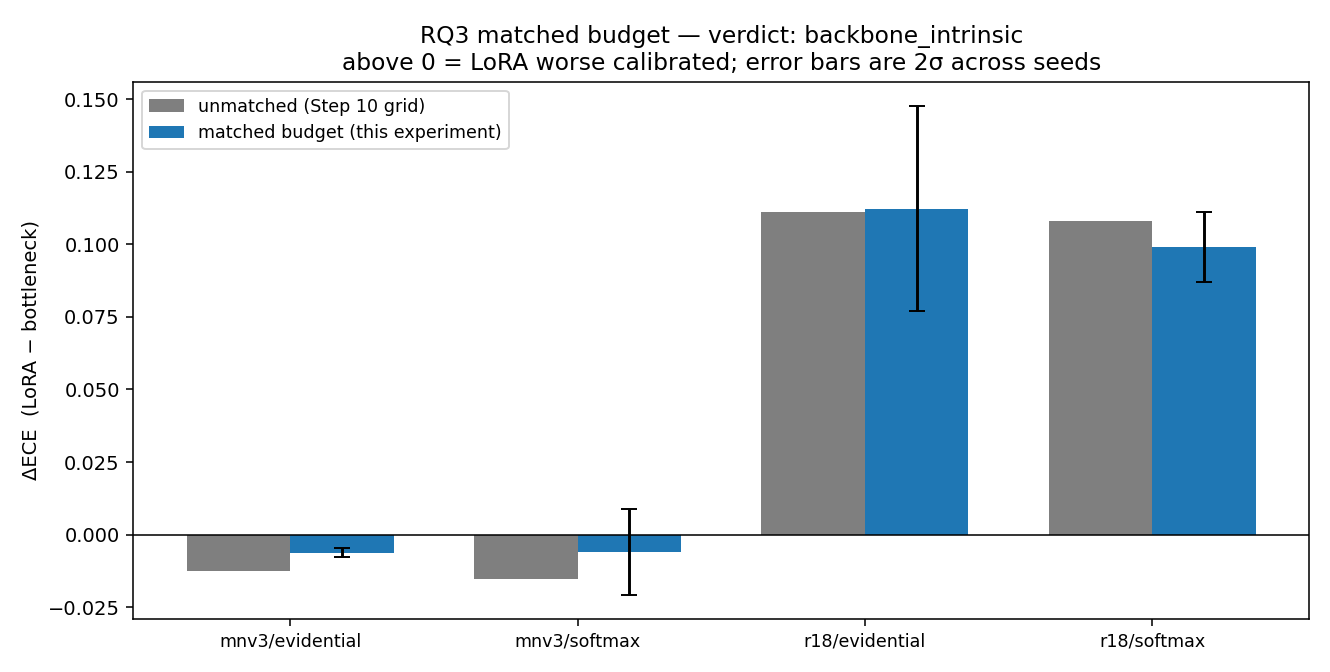

In [11]:
# The picture the experiment is: does the sign flip survive budget equalisation?
if RUN_VERDICT and VERDICT['decision']['cells']:
    import numpy as np
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt

    keys = sorted(VERDICT['decision']['cells'])
    cs = [VERDICT['decision']['cells'][k] for k in keys]
    x = np.arange(len(keys)); w = 0.36
    fig, ax = plt.subplots(figsize=(9.5, 4.8))
    ax.bar(x - w / 2, [c['delta_ece_unmatched'] for c in cs], w,
           color='tab:gray', label='unmatched (Step 10 grid)')
    ax.bar(x + w / 2, [c['delta_ece_matched'] for c in cs], w,
           yerr=[M.SIGMA_MULTIPLE * c['sigma_ece'] for c in cs], capsize=4,
           color='tab:blue', label='matched budget (this experiment)')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([k.replace('mobilenetv3_small', 'mnv3').replace('resnet18', 'r18')
                        for k in keys], fontsize=9)
    ax.set_ylabel('ΔECE  (LoRA − bottleneck)')
    ax.set_title(f'RQ3 matched budget — verdict: {VERDICT["verdict"]}\n'
                 'above 0 = LoRA worse calibrated; error bars are 2σ across seeds')
    ax.legend(fontsize=9)
    fig.tight_layout()
    out_png = REPO / 'results' / 'rq3_matched_delta_ece.png'
    fig.savefig(out_png, dpi=140)
    print('wrote', out_png)
    from IPython.display import Image, display
    display(Image(filename=str(out_png)))


## 9. Pack + push artifacts

Two zips on purpose. The **results** zip is small and always pushable. The **checkpoints** zip is
~600 MB, and a failed push of that must not take the results with it — but attaching it next session
is exactly what makes the sweep resume instead of retraining.

The session log travels with the results: the Step 11 incident was only diagnosable because a log
survived, and it did so by luck.


In [12]:
import glob, hashlib, zipfile

def _pack(zip_path, files, stem):
    files = [p for p in files if os.path.exists(p)]
    if not files:
        print(f'  {stem}: nothing to pack'); return None
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        for p in files:
            zf.write(p)
        zf.writestr('MANIFEST.txt', '\n'.join(
            f'{p}  {os.path.getsize(p)}B  '
            f'sha256={hashlib.sha256(open(p, "rb").read()).hexdigest()}'
            for p in files))
    mb = os.path.getsize(zip_path) / 1e6
    print(f'  wrote {zip_path} ({len(files)} files, {mb:.1f} MB)')
    return zip_path

WORK = '/kaggle/working' if os.path.isdir('/kaggle/working') else str(REPO.parent)

results_files = (
    sorted(glob.glob('results/rq3_matched/*')) +
    sorted(glob.glob('configs/rq3_matched/*')) +
    ['results/rq3_matched_session.log', 'results/rq3_matched_delta_ece.png',
     'rq3_matched.py']
)
zip_results = _pack(f'{WORK}/rq3_matched_results.zip', results_files, 'results')

# Only THIS experiment's checkpoints -- the reused Step 10 twins already live in
# their own dataset and re-packing them would double the upload for nothing.
ckpt_files = sorted(p for p in glob.glob('checkpoints/model_phase2_rq3m_*.pt'))
zip_ckpts = (_pack(f'{WORK}/rq3_matched_checkpoints.zip', ckpt_files, 'checkpoints')
             if PACK_CHECKPOINTS else None)
zip_logits = (_pack(f'{WORK}/rq3_matched_logits.zip',
                    sorted(glob.glob('results/rq3_matched_logits/*.npz')), 'logits')
              if PERSIST_LOGITS else None)

try:
    from kaggle_secrets import UserSecretsClient
    _s = UserSecretsClient()
    os.environ['KAGGLE_USERNAME'] = _s.get_secret('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = _s.get_secret('KAGGLE_KEY')
    HAVE_SECRETS = True
except Exception:
    HAVE_SECRETS = False

for zp, stem in ((zip_results, 'rq3-matched-results'),
                 (zip_ckpts, 'rq3-matched-checkpoints'),
                 (zip_logits, 'rq3-matched-logits')):
    if zp is None:
        continue
    if HAVE_SECRETS:
        ds_dir = f'{WORK}/{stem}_dataset'
        os.makedirs(ds_dir, exist_ok=True)
        subprocess.run(['cp', zp, ds_dir], check=True)
        json.dump({'title': stem,
                   'id': f"{os.environ['KAGGLE_USERNAME']}/{stem}",
                   'licenses': [{'name': 'CC0-1.0'}]},
                  open(f'{ds_dir}/dataset-metadata.json', 'w'))
        r = subprocess.run(['kaggle', 'datasets', 'create', '-p', ds_dir, '-q'],
                           capture_output=True, text=True)
        if r.returncode != 0:
            subprocess.run(['kaggle', 'datasets', 'version', '-p', ds_dir,
                            '-m', 'update', '-q'])
        print(f'  pushed Kaggle dataset: {stem}')
    else:
        from IPython.display import FileLink, display
        display(FileLink(zp))
print('\nNo Kaggle Secrets -> use the download links above.' if not HAVE_SECRETS
      else '\nPushed. These survive the tab closing.')


  wrote /kaggle/working/rq3_matched_results.zip (102 files, 0.2 MB)
  wrote /kaggle/working/rq3_matched_checkpoints.zip (48 files, 1084.3 MB)


/kaggle/working/rq3_matched_results.zip

/kaggle/working/rq3_matched_checkpoints.zip


No Kaggle Secrets -> use the download links above.


## After this session

1. **Read the acceptance block at the end of Section 8 first.** It is §7's checklist, computed
   rather than asserted. `all_runs_complete` is the one that decides whether the verdict means
   anything — a partial sweep is deliberately reported as `inconclusive` no matter how suggestive
   the numbers look.

2. **If cells are left, run again.** Attach `rq3-matched-results` **and**
   `rq3-matched-checkpoints` from this session (plus the same step10c dataset), then re-run top to
   bottom. Section 5 restores both and the sweep resumes at the next cell. Expect 2–3 sessions.

3. **Check `reused_arm_reproduction` before quoting anything.** Every existing-arm cell should be
   `exact` or `within_tol` against the committed Step 10 metrics. Anything else means this harness
   is not measuring what the grid measured, and the matched-vs-unmatched contrast is not clean.

4. **Report the residual budget mismatch, not "identical arms."** It is 0.43–3.10% here, against
   55–158% in the original comparison. That is the honest framing and it is still a 20–130× tightening.

5. **When the sweep is complete**, promote the results into the thesis text:
   - `results/rq3_matched/verdict.json` → the RQ3 §8 section of `docs/RQ_RESULTS_SUMMARY.md`,
     replacing the "identification limits" paragraph with whichever of H3.1 / H3.2 / H3.2-alt the
     pre-registered rule named — or with the inconclusive finding, stated plainly.
   - `rq3_matched.py` → `scripts/rq3_matched.py`.
   - `results/rq3_matched_delta_ece.png` → the figure for that section.
   - a Step entry in `progress.txt` with the decisions log line.

6. **If the verdict is `inconclusive`, that is a result, not a failure.** Plan §9 already states the
   fallback: report H3.2 as the better-supported of two live explanations, name H3.2-alt explicitly,
   and say what would discriminate them. Do not narrate a preferred story from a null.
